In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle

df = pd.read_csv("train.csv")
df.isnull().sum()
df.duplicated().sum()
df.shape
df.head()
pd.set_option("display.max_columns",None)
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [3]:
df["age"] = df["age"].astype(np.int32)
for col in df.columns:
    numerical_features = ["ID","age","result"]
    if col not in numerical_features:
        print(col,df[col].unique())
        print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender ['f' 'm']
--------------------------------------------------
ethnicity ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
--------------------------------------------------
jaundice ['no' 'yes']
--------------------------------------------------
austim

In [4]:
df = df.drop(columns=["ID","age_desc"])

In [5]:
mapping = {"Viet Nam" : "Vietnam","AmericanSamoa":"United States"}
df["contry_of_res"] = df["contry_of_res"].replace(mapping)

In [6]:
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

In [7]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


# Univariable Analysis

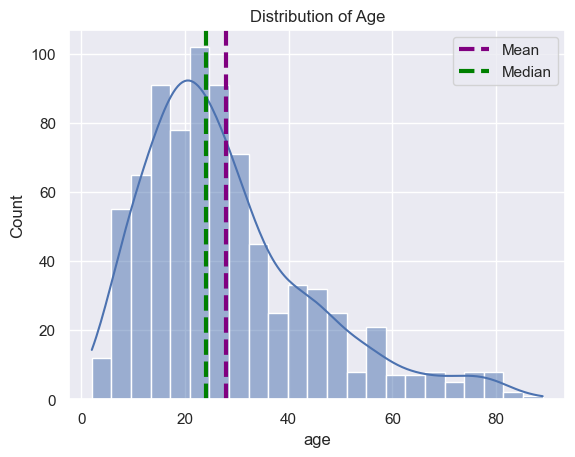

In [8]:
sns.set_theme(style="darkgrid")
sns.histplot(df["age"],kde=True)
plt.title("Distribution of Age")
age_mean = df["age"].mean()
age_median = df["age"].median()
plt.axvline(age_mean,linestyle="--",linewidth=3,color="purple",label="Mean")
plt.axvline(age_median,linestyle="--",linewidth=3,color="green",label="Median")
plt.legend()
plt.show()

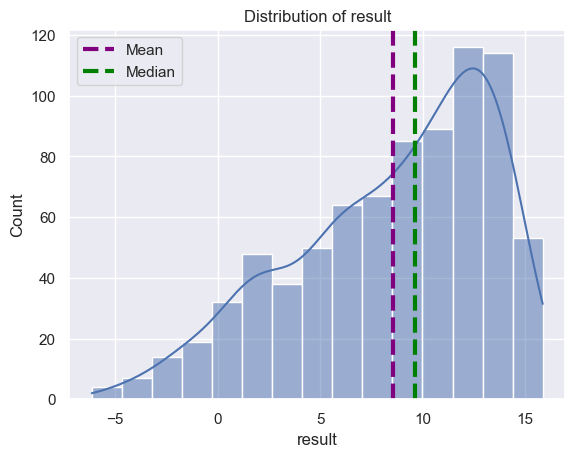

In [9]:
sns.histplot(df["result"],kde=True)
plt.title("Distribution of result")
result_mean = df["result"].mean()
result_median = df["result"].median()
plt.axvline(result_mean,linestyle="--",linewidth=3,color="purple",label="Mean")
plt.axvline(result_median,linestyle="--",linewidth=3,color="green",label="Median")
plt.legend()
plt.show()

# Box Plots for identifying outliers in numerical columns

Text(0.5, 0, 'Age')

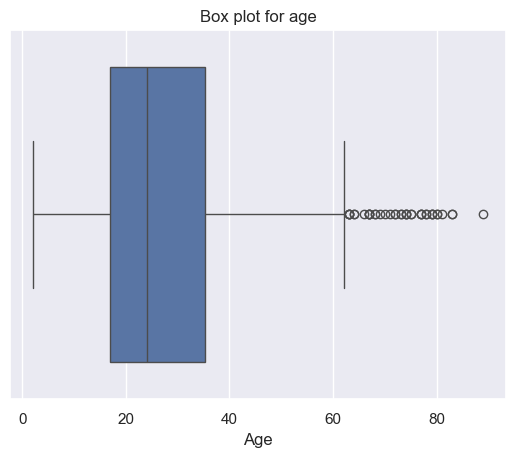

In [10]:
sns.boxplot(x=df["age"])
plt.title("Box plot for age")
plt.xlabel("Age")


Text(0.5, 0, 'result')

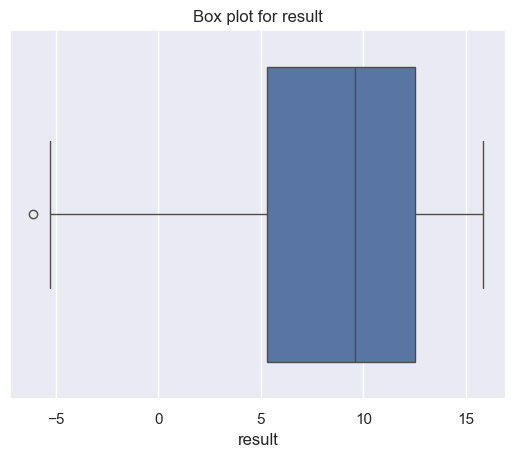

In [11]:
sns.boxplot(x=df["result"])
plt.title("Box plot for result")
plt.xlabel("result")

In [12]:
# Counting Outliers using IQR method
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
age_outlier = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]
len(age_outlier) + len(df[df["age"] > 100])

39

In [13]:
Q1 = df["result"].quantile(0.25)
Q3 = df["result"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1-1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
result_outlier = df[(df["result"] < lower_bound) | (df["result"] > upper_bound)]
len(result_outlier) + len(df[df["result"] > 100])

1

# Analysis on Categorical columns

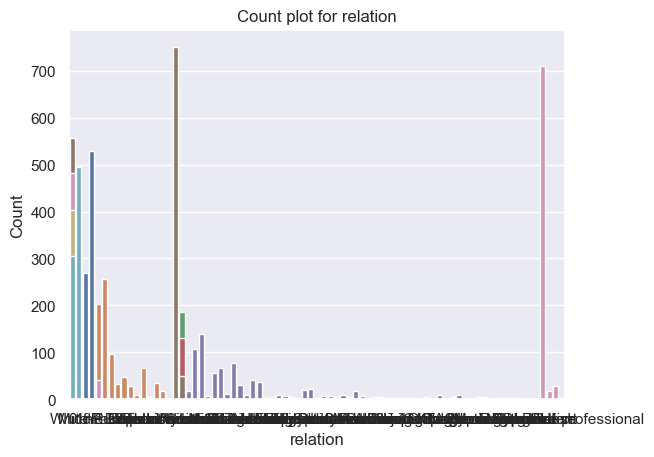

In [14]:
categorical_columns = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']
# df.columns
for col in categorical_columns:
    sns.countplot(x=df[col])
    # plt.subplot(2,1,1)
    plt.title(f"Count plot for {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

In [15]:
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

# handling missing values 

In [16]:
df["ethnicity"] = df["ethnicity"].replace({"?":"others","Others":"others"})

In [17]:
df["relation"] = df["relation"].replace({"?" : "others","Parent" : "others","Relative":"others","Health care professional" : "others"})

In [18]:
df.head()
# df[df["relation"] == "others"]

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,others,no,no,Austria,no,6.351166,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,others,no,no,India,no,2.255185,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,others,no,no,United States,no,2.276617,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,others,no,no,South Africa,no,-4.777286,Self,0


In [19]:
object_column = df.select_dtypes(include=["object"]).columns
encoders = {}

for column in object_column:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [20]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

In [21]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,9,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,9,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,8,0,1,53,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,9,0,0,53,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,9,0,0,45,0,-4.777286,1,0


Text(0.5, 1.0, 'Correlation Heatmap')

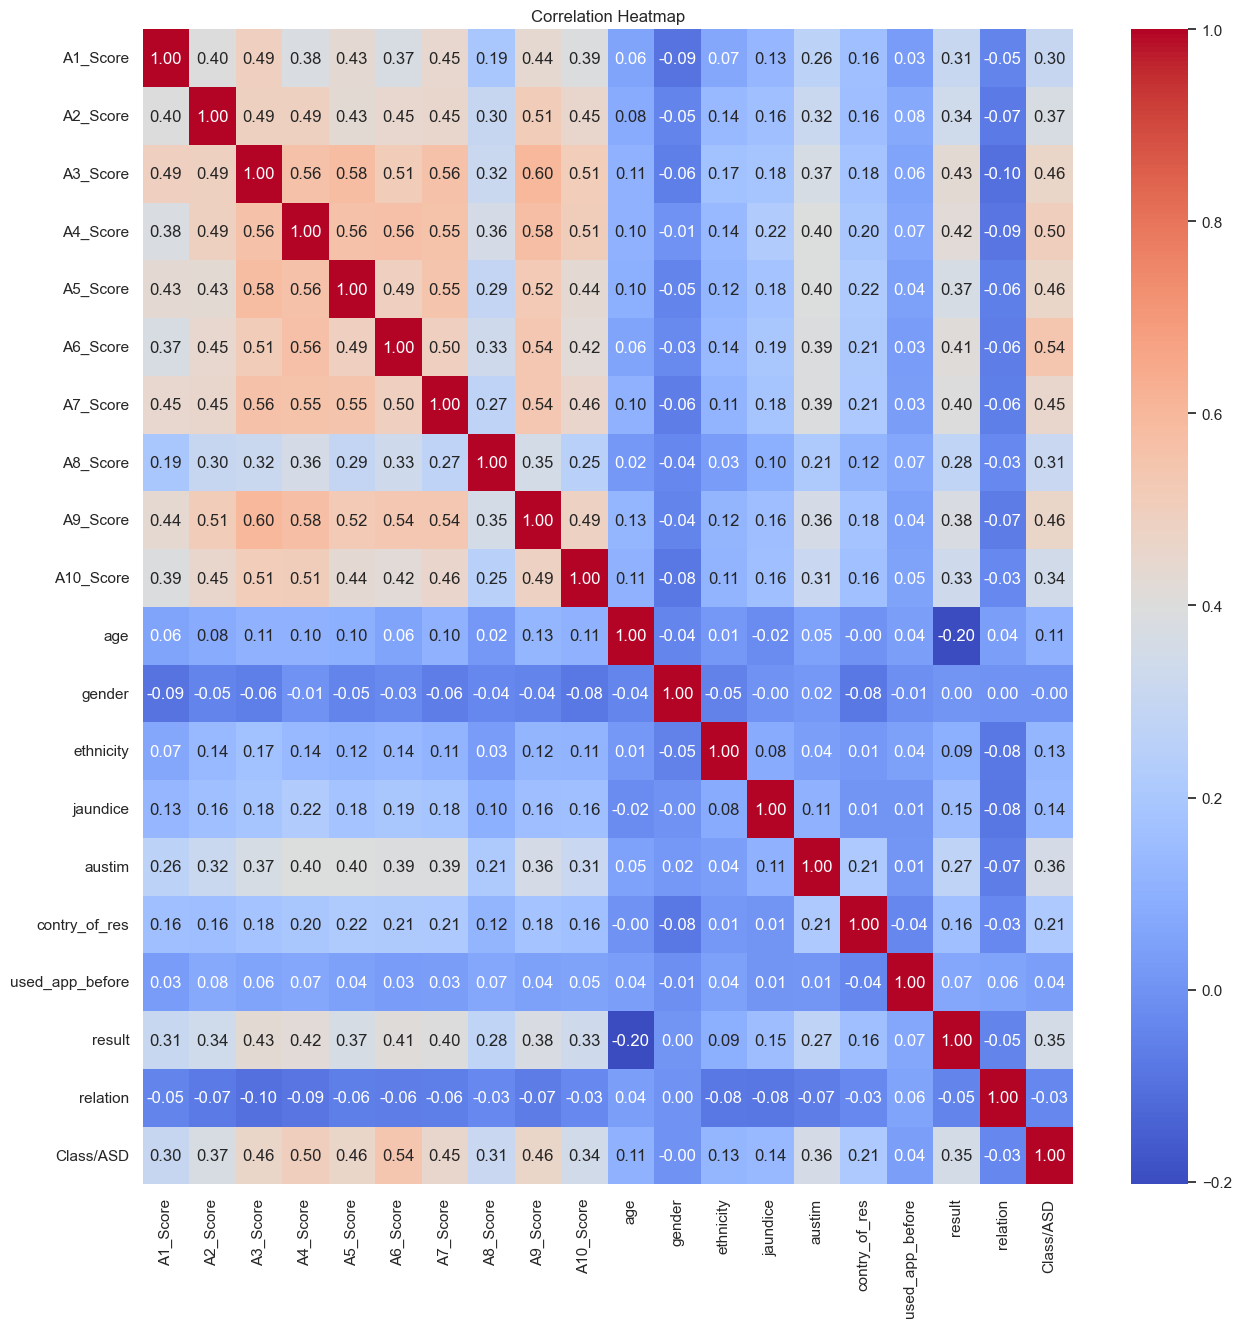

In [22]:
# correlation_matrix
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")

In [23]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,9,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,9,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,8,0,1,53,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,9,0,0,53,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,9,0,0,45,0,-4.777286,1,0


# Insights from EDA
- There are few outliers in numerical columns (age,result)
- There is a class imbalance in the taget columns
- There is a class imbalance in the categorical features
- We dont have any highly correlated column
- Performed Label encoding and saved the encoders
  

# Data Preprocessing

In [24]:
# Handling the outliers
def replace_outliers_with_median(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1-1.5 * IQR
    upper_bound = Q1+1.5 * IQR

    median = df[column].median()
    df[column] = df[column].apply(lambda x : median if x < lower_bound or x > upper_bound else x)
    
    return df
df = replace_outliers_with_median(df,"age")
df = replace_outliers_with_median(df,"result")

df.to_csv("final_data.csv",index=False)


In [25]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,9,0,0,6,0,6.351166,1,0
1,0,0,0,0,0,0,0,0,0,0,24.0,1,9,0,0,24,0,2.255185,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,8,0,1,53,0,14.851484,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,9,0,0,53,0,2.276617,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,9,0,0,45,0,-4.777286,1,0


In [27]:
y_train.value_counts()

Class/ASD
0    511
1    129
Name: count, dtype: int64